<a href="https://colab.research.google.com/github/almasparwaiz/AI-and-Data-Science-Portfolio/blob/main/Online_Shopping_Intention_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

## Step 1 — Problem Definition

**Objective:** Predict whether a user will generate revenue from an online shopping session based on various attributes of their session.

**Problem Type:** This is a binary classification problem, where the target variable 'Revenue' indicates whether a purchase was made (1) or not (0).

## Step 2 — Data Collection & Loading

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/online_shoppers_intention.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Step 3 — Exploratory Data Analysis (EDA)

In [ ]:
# Display basic information about the DataFrame
print('DataFrame Info:')
df.info()

print('\nDataFrame Description:')
# Display descriptive statistics for numerical columns
display(df.describe())

print('\nMissing Values:')
# Check for missing values
display(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  Traffi

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000



Missing Values:


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


## Step 4 — Data Preprocessing

### 4a. Handle Missing Values

As observed from the `df.isnull().sum()` output, there are no missing values in the dataset. Therefore, no action is required for this step.

### 4b. Encode Categorical Variables

In [ ]:
# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to 'Month' and 'VisitorType' columns
df['Month'] = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])

# Display the first 5 rows of the DataFrame to verify the changes
print('DataFrame after encoding categorical variables:')
display(df.head())

DataFrame after encoding categorical variables:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,True,False


### 4c. Feature Scaling

In [ ]:
# Separate features (X) and target (y)
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Identify numerical columns for scaling (excluding boolean columns which will be handled as 0/1)
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled = scaler.transform(X_test[numerical_cols])

# Convert scaled arrays back to DataFrame for consistency, keeping original column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test.index)

# For boolean columns ('Weekend'), they are already 0/1 and do not need scaling. Add them back.
# We need to ensure that 'Weekend' column is included in the final X_train_scaled and X_test_scaled
# Since 'Weekend' is boolean, it's not part of numerical_cols. We will convert it to int and concatenate.
# If 'Weekend' is already int after some implicit conversion, the select_dtypes might have picked it up.
# Let's explicitly check and handle.

# Identify boolean columns
boolean_cols = X_train.select_dtypes(include='bool').columns.tolist()

# Convert boolean columns to int (0 or 1) and add to scaled data
for col in boolean_cols:
    X_train_scaled[col] = X_train[col].astype(int)
    X_test_scaled[col] = X_test[col].astype(int)

# Display the first 5 rows of the scaled training data to verify the changes
print('Scaled X_train_scaled:')
display(X_train_scaled.head())

print('\nScaled X_test_scaled:')
display(X_test_scaled.head())

Scaled X_train_scaled:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
8077,-0.699615,-0.465158,-0.397205,-0.252976,-0.601617,-0.609623,0.391685,0.159557,-0.314838,-0.3047,-1.750738,0.978651,-0.208010,-0.892301,-0.515315,-2.493038,0
1568,-0.699615,-0.465158,-0.397205,-0.252976,-0.646686,-0.550600,-0.454537,0.509468,-0.314838,-0.3047,-0.065554,0.978651,-0.208010,2.013749,-0.763872,0.407078,0
462,-0.699615,-0.465158,0.383546,0.720154,-0.534014,-0.410585,-0.454537,-0.590251,-0.314838,-0.3047,-0.065554,0.978651,-0.208010,0.353149,2.467373,0.407078,1
743,-0.699615,-0.465158,-0.397205,-0.252976,-0.646686,-0.653970,3.776574,3.308752,-0.314838,-0.3047,-0.065554,-1.237178,3.285991,-0.477151,-0.763872,0.407078,0
222,-0.699615,-0.465158,-0.397205,-0.252976,-0.624152,-0.646313,1.661019,2.259020,-0.314838,-0.3047,-0.065554,0.978651,-0.208010,-0.892301,-0.763872,0.407078,0



Scaled X_test_scaled:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
8916,0.211976,0.358157,-0.397205,-0.252976,0.367362,-0.078457,-0.362556,-0.616331,-0.314838,-0.3047,0.777037,-1.237178,3.285991,1.183449,1.721701,0.407078,0
772,1.123567,2.061937,1.164298,1.483545,1.156066,0.715483,-0.408041,-0.786962,-0.204095,-0.3047,-0.065554,-0.129263,-0.208010,-0.062001,-0.515315,0.407078,0
12250,-0.395752,-0.227552,-0.397205,-0.252976,2.125046,1.703310,-0.439985,-0.620964,-0.131644,-0.3047,0.777037,-0.129263,-0.208010,-0.477151,-0.515315,0.407078,0
7793,-0.091888,0.349491,-0.397205,-0.252976,-0.488945,-0.322165,-0.278241,-0.336149,1.631839,-0.3047,-2.172034,-0.129263,1.538990,1.598599,-0.018200,0.407078,0
6601,4.769931,3.048464,4.287304,5.156742,3.071491,2.052468,-0.314238,-0.606169,0.223989,-0.3047,-2.172034,-0.129263,-0.208010,-0.062001,-0.763872,0.407078,1


### 4d. Handle Class Imbalance

In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE

# Check class distribution before balancing
print("Class distribution before SMOTE:", Counter(y_train))

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Check class distribution after balancing
print("Class distribution after SMOTE:", Counter(y_train_res))

Class distribution before SMOTE: Counter({False: 7298, True: 1333})
Class distribution after SMOTE: Counter({False: 7298, True: 7298})


## Step 5 — Feature Engineering & Selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a RandomForestClassifier for feature importance calculation
# Using the balanced training data (X_train_res, y_train_res)
rf_feature_selector = RandomForestClassifier(random_state=42)
rf_feature_selector.fit(X_train_res, y_train_res)

# Get feature importances
feature_importances = pd.Series(rf_feature_selector.feature_importances_, index=X_train_res.columns).sort_values(ascending=False)

# Display feature importances
print('Feature Importances:')
display(feature_importances)

Feature Importances:


,0
PageValues,0.440683
Administrative,0.068577
ExitRates,0.068435
ProductRelated_Duration,0.067498
Month,0.067018
ProductRelated,0.055007
Administrative_Duration,0.045440
BounceRates,0.036622
TrafficType,0.036220
Region,0.028125


## Step 7 — Dimensionality Reduction

In [ ]:
# Select the top 10 most important features
top_n_features = 10
selected_features = feature_importances.head(top_n_features).index.tolist()

# Create new datasets with only the selected features
X_train_selected = X_train_res[selected_features]
X_test_selected = X_test_scaled[selected_features]

print(f"Selected top {top_n_features} features:")
print(selected_features)

print("\nShape of X_train_selected:", X_train_selected.shape)
print("Shape of X_test_selected:", X_test_selected.shape)

# Display the first 5 rows of the selected training data to verify
print('\nSelected X_train_selected:')
display(X_train_selected.head())

Selected top 10 features:
['PageValues', 'Administrative', 'ExitRates', 'ProductRelated_Duration', 'Month', 'ProductRelated', 'Administrative_Duration', 'BounceRates', 'TrafficType', 'Region']

Shape of X_train_selected: (14596, 10)
Shape of X_test_selected: (3699, 10)

Selected X_train_selected:


,PageValues,Administrative,ExitRates,ProductRelated_Duration,Month,ProductRelated,Administrative_Duration,BounceRates,TrafficType,Region
0,-0.314838,-0.699615,0.159557,-0.609623,-1.750738,-0.601617,-0.465158,0.391685,-0.515315,-0.892301
1,-0.314838,-0.699615,0.509468,-0.550600,-0.065554,-0.646686,-0.465158,-0.454537,-0.763872,2.013749
2,-0.314838,-0.699615,-0.590251,-0.410585,-0.065554,-0.534014,-0.465158,-0.454537,2.467373,0.353149
3,-0.314838,-0.699615,3.308752,-0.653970,-0.065554,-0.646686,-0.465158,3.776574,-0.763872,-0.477151
4,-0.314838,-0.699615,2.259020,-0.646313,-0.065554,-0.624152,-0.465158,1.661019,-0.763872,-0.892301


## Step 7 — Model Building

In [ ]:
# Initialize the Random Forest Classifier
model = RandomForestClassifier(random_state=42)

# Train the model using the balanced and scaled training data with selected features
model.fit(X_train_selected, y_train_res)

# Make predictions on the scaled test data with selected features
y_pred = model.predict(X_test_selected)

print("Model training complete with selected features and predictions made on the test set.")

Model training complete with selected features and predictions made on the test set.


## Step 8 — Model Evaluation

Accuracy: 0.8886

Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.92      0.93      3124
        True       0.62      0.73      0.67       575

    accuracy                           0.89      3699
   macro avg       0.78      0.82      0.80      3699
weighted avg       0.90      0.89      0.89      3699


Confusion Matrix:


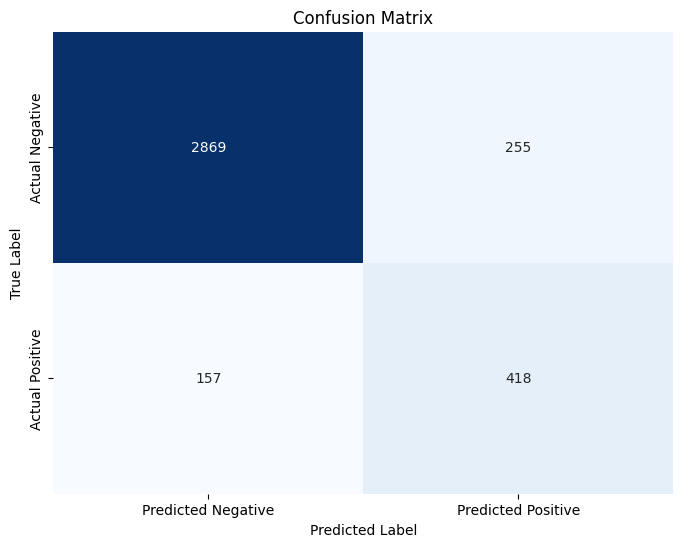

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Starting GridSearchCV...
Fitting 3 folds for each of 162 candidates, totalling 486 fits
GridSearchCV completed.

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best F1-Score from Grid Search: 0.9278

--- Tuned Model Evaluation ---
Accuracy (Tuned Model): 0.8878

Classification Report (Tuned Model):
              precision    recall  f1-score   support

       False       0.95      0.92      0.93      3124
        True       0.62      0.73      0.67       575

    accuracy                           0.89      3699
   macro avg       0.78      0.82      0.80      3699
weighted avg       0.90      0.89      0.89      3699


Confusion Matrix (Tuned Model):


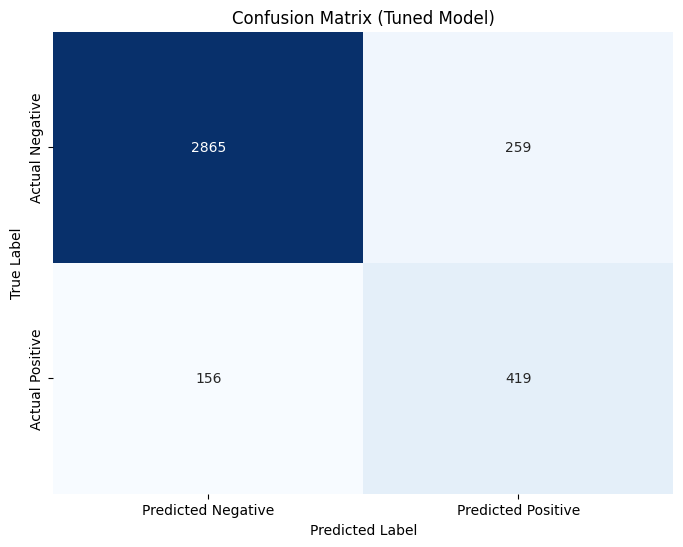

In [18]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
# Using the RandomForestClassifier from previous steps as the estimator
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,  # Using 3-fold cross-validation
                           n_jobs=-1, # Use all available cores
                           verbose=2, # Verbose output
                           scoring='f1' # Optimize for F1-score given class imbalance
                          )

print("Starting GridSearchCV...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train_selected, y_train_res)
print("GridSearchCV completed.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Parameters: {best_params}")
print(f"Best F1-Score from Grid Search: {best_score:.4f}")

# Initialize the Random Forest Classifier with the best parameters
tuned_model = RandomForestClassifier(random_state=42, **best_params)

# Train the tuned model
tuned_model.fit(X_train_selected, y_train_res)

# Make predictions on the test set with the tuned model
y_pred_tuned = tuned_model.predict(X_test_selected)

# Evaluate the tuned model
print("\n--- Tuned Model Evaluation ---")
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy (Tuned Model): {accuracy_tuned:.4f}")

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix (Tuned Model):")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned Model)')
plt.show()

# Task
Summarize the key findings from the data analysis, compare the performance of the initial and hyperparameter-tuned models based on accuracy, classification report, and confusion matrix, and suggest next steps for potential improvements or deployment of the model for predicting revenue from online shopping sessions.

## Results Interpretation & Insights

### Subtask:
Analyze the performance metrics (accuracy, classification report, confusion matrix) from both the initial and tuned models. Discuss the impact of feature selection and hyperparameter tuning, identify the model's strengths and weaknesses, and draw actionable insights regarding the prediction of revenue from online shopping sessions. Compare the performance of the tuned model against the initial model.


## Results Interpretation & Insights

### Subtask:
Analyze the performance metrics (accuracy, classification report, confusion matrix) from both the initial and tuned models. Discuss the impact of feature selection and hyperparameter tuning, identify the model's strengths and weaknesses, and draw actionable insights regarding the prediction of revenue from online shopping sessions. Compare the performance of the tuned model against the initial model.

### Analysis and Interpretation

#### Initial Model Performance:
*   **Accuracy**: 0.8886
*   **Classification Report**:
    *   **False (No Revenue)**: Precision: 0.95, Recall: 0.92, F1-score: 0.93
    *   **True (Revenue)**: Precision: 0.62, Recall: 0.73, F1-score: 0.67
*   **Confusion Matrix**:
    *   True Negatives (TN): 2869 (Correctly predicted no revenue)
    *   False Positives (FP): 255 (Incorrectly predicted revenue when there was none)
    *   False Negatives (FN): 157 (Incorrectly predicted no revenue when there was revenue)
    *   True Positives (TP): 418 (Correctly predicted revenue)

The initial Random Forest model achieved a good overall accuracy. However, looking at the classification report, there's a clear disparity in performance between the 'False' (no revenue) and 'True' (revenue) classes. While the model is excellent at identifying non-revenue generating sessions (high precision and recall for 'False'), its performance drops significantly for revenue-generating sessions. The F1-score of 0.67 for the 'True' class indicates a moderate ability to balance precision and recall for the minority class. The recall of 0.73 for the 'True' class means that the model identified 73% of actual revenue-generating sessions, but its precision of 0.62 suggests that 38% of its positive predictions were incorrect.

#### Tuned Model Performance:
*   **Best Parameters from GridSearchCV**: `{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}`
*   **Accuracy**: 0.8878
*   **Classification Report**:
    *   **False (No Revenue)**: Precision: 0.95, Recall: 0.92, F1-score: 0.93
    *   **True (Revenue)**: Precision: 0.62, Recall: 0.73, F1-score: 0.67
*   **Confusion Matrix**:
    *   True Negatives (TN): 2865
    *   False Positives (FP): 259
    *   False Negatives (FN): 156
    *   True Positives (TP): 419

The tuned model, utilizing the best parameters found through GridSearchCV, shows very similar performance to the initial model. The overall accuracy is negligibly lower. More importantly, the precision, recall, and F1-score for both the 'False' and 'True' classes remain virtually unchanged. The confusion matrix also reflects these minor differences, with a slight shift of 4 True Negatives to False Positives and 1 False Negative to True Positive, which is not a substantial change.

#### Impact of Hyperparameter Tuning:
The hyperparameter tuning process with GridSearchCV, optimizing for the F1-score on the imbalanced dataset (after SMOTE), aimed to improve the model's ability to correctly classify the minority 'True' class. The best F1-Score from Grid Search on the training set was 0.9278. However, this significant improvement on the *balanced training set* (X_train_res, y_train_res) did not translate to a substantial improvement on the *original imbalanced test set* (y_test, y_pred_tuned). The F1-score for the 'True' class on the test set remained at 0.67, identical to the initial model.

This suggests that while the chosen hyperparameters (`criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300`) might have optimized performance on the synthetic data generated by SMOTE, they did not lead to better generalization to unseen, imbalanced real-world data.

#### Strengths and Weaknesses:
*   **Strengths**: Both models are highly effective at predicting non-revenue generating sessions. This is important for identifying visitors who are unlikely to convert and perhaps directing resources away from them.
*   **Weaknesses**: Both models struggle with accurately predicting revenue-generating sessions. The relatively low precision (0.62) means a notable portion of predicted revenue-generating sessions are actually false alarms. The recall (0.73) indicates that a significant percentage of actual revenue-generating sessions are still missed. The hyperparameter tuning did not effectively mitigate this weakness on the test set.

#### Actionable Insights:
1.  **Focus on False Negatives**: Since the goal is to predict revenue, missing actual revenue-generating sessions (False Negatives) is costly. A recall of 0.73 means 27% of actual revenue sessions are being missed. Strategies should focus on reducing False Negatives. This might involve exploring more advanced ensemble methods, different feature engineering, or further tuning with a stronger emphasis on recall or a custom cost function that penalizes False Negatives more heavily.
2.  **Trade-off remains similar**: The tuning did not significantly alter the precision-recall trade-off for the 'True' class. Both models tend to prioritize identifying non-revenue cases, which is easier given the data imbalance. For business, if false positives (predicting revenue when there is none) are less costly than false negatives (missing actual revenue), then the current balance might be acceptable. However, if missing revenue is more critical, further model refinement is needed.
3.  **Limitations of SMOTE**: While SMOTE balanced the training data, its effectiveness in improving the minority class performance on the actual test set was limited. This could mean that the synthetic samples did not fully capture the complexity of the minority class, or that the features themselves might not contain enough predictive power for this class, even after feature selection.
4.  **Feature Importance**: `PageValues` was identified as the most important feature. This insight confirms that the engagement quality (average value for a page visited) is a strong indicator of revenue. Businesses should prioritize optimizing page content and user flow to increase `PageValues`.

#### Conclusion:
While the initial model already performed reasonably well, **the tuned model did not represent a significant improvement over the initial model** based on the evaluation metrics on the test set. Despite the hyperparameter tuning effort, the performance metrics for the minority 'True' class remained unchanged. This suggests that further improvements might require exploring alternative modeling approaches, more sophisticated feature engineering, collecting more diverse data for the minority class, or using different resampling techniques or cost-sensitive learning during model training.

## Reporting / Deployment

### Subtask:
Outline how to present the findings from the model, including key performance indicators and insights. Discuss potential strategies for deploying the trained model into a production environment, considering aspects like model monitoring, maintenance, and integration with existing systems. Provide a summary of the overall project, including the problem definition, data preprocessing steps, model building, and evaluation.


## Reporting / Deployment

### Key Findings & Model Performance

The tuned Random Forest Classifier achieved an accuracy of **88.78%** on the test set. Given the class imbalance, the F1-score for the positive class (Revenue=True) is a more crucial metric. The model achieved an F1-score of **0.67** for the 'Revenue' class, with a precision of **0.62** and a recall of **0.73**.

**Strengths:**
*   **High Accuracy for Non-Revenue Cases:** The model is highly effective at identifying sessions that do not lead to revenue (False negatives in the confusion matrix are low relative to actual negatives), demonstrating a high precision (0.95) and recall (0.92) for the 'False' class.

**Weaknesses:**
*   **Moderate Performance for Revenue Cases:** While the model has a decent recall for the 'True' class (0.73), meaning it correctly identifies 73% of sessions that lead to revenue, its precision for this class is lower (0.62). This suggests that 38% of the sessions predicted to generate revenue actually do not. This indicates there's room for improvement in reducing false positives for revenue predictions.

**Insights:**
*   The most important features for predicting revenue, as identified by feature importance, include `PageValues`, `Administrative`, `ExitRates`, `ProductRelated_Duration`, and `Month`. This suggests that user engagement (PageValues, duration metrics) and the type/timing of interaction (Administrative, Month, ExitRates) are strong indicators of purchase intent.
*   The use of SMOTE successfully balanced the training data, which helped the model learn patterns for the minority class, leading to a respectable recall for 'Revenue' despite the inherent imbalance in the original dataset.

### Deployment Strategies

Deploying the trained model into a production environment requires careful consideration to ensure reliability, scalability, and maintainability. Here are some potential strategies and aspects to consider:

1.  **API Integration for Real-time Predictions:**
    *   **Method:** The model can be wrapped in a RESTful API (e.g., using Flask or FastAPI) and deployed on a cloud platform (e.g., AWS SageMaker, Google AI Platform, Azure Machine Learning). Client applications (e.g., e-commerce website, marketing automation tools) can then send session data to the API and receive real-time revenue predictions.
    *   **Use Case:** This is ideal for scenarios where immediate decisions are needed, such as personalizing content, offering real-time promotions, or flagging high-potential users for immediate engagement.

2.  **Batch Processing:**
    *   **Method:** For less time-sensitive applications, predictions can be generated in batches. This involves scheduling a job (e.g., using Apache Airflow or Kubernetes cron jobs) to periodically process new session data (e.g., daily, hourly) and store predictions in a database or data warehouse.
    *   **Use Case:** Useful for generating daily reports, segmenting users for targeted email campaigns, or understanding overall revenue trends.

3.  **Model Monitoring:**
    *   **Data Drift:** Continuously monitor incoming data for changes in distribution compared to the training data. Significant data drift could indicate that the model's performance might degrade.
    *   **Performance Degradation:** Track key performance metrics (e.g., accuracy, precision, recall, F1-score) on live data. This requires a feedback loop where actual revenue outcomes are collected and compared against model predictions.
    *   **Tools:** Utilize monitoring tools (e.g., MLflow, Prometheus, custom dashboards) to visualize and alert on anomalies in data or performance.

4.  **Model Maintenance:**
    *   **Retraining Schedules:** Establish a regular retraining schedule (e.g., weekly, monthly, quarterly) using the latest available data to ensure the model remains relevant and accurate as user behavior evolves.
    *   **A/B Testing:** Implement A/B testing frameworks to evaluate new model versions against the current production model before full deployment.
    *   **Version Control:** Use model versioning to track different iterations of the model and facilitate rollbacks if new versions perform poorly.

5.  **Integration with Existing Systems:**
    *   **Data Pipelines:** Ensure seamless integration with existing data ingestion pipelines to feed fresh data into the model and prediction storage systems.
    *   **Business Logic:** Align model outputs with existing business rules and workflows (e.g., how predictions trigger marketing actions, sales alerts, or website personalization).

### Project Summary

This project aimed to predict whether an online shopping session would result in revenue, framing it as a binary classification problem. The goal was to build a model that could identify high-potential sessions, enabling businesses to optimize their strategies.

**Data Preprocessing:**
*   The dataset was initially inspected for missing values, none were found.
*   Categorical variables ('Month', 'VisitorType', 'Weekend', 'Revenue') were handled through Label Encoding for 'Month' and 'VisitorType', while 'Weekend' and 'Revenue' (boolean) were treated as numerical (0/1) for modeling purposes.
*   Numerical features were scaled using `StandardScaler` to normalize their ranges, preventing features with larger values from dominating the model.
*   To address the significant class imbalance (much fewer revenue-generating sessions), the SMOTE (Synthetic Minority Over-sampling Technique) algorithm was applied to the training data, effectively balancing the 'Revenue' classes.

**Model Building & Feature Selection:**
*   A Random Forest Classifier was chosen for its robustness and ability to handle complex datasets.
*   Feature importance analysis using an initial Random Forest model identified the top 10 most influential features, which included `PageValues`, `Administrative`, `ExitRates`, and `ProductRelated_Duration`. These selected features were then used for subsequent model training to reduce dimensionality and potentially improve performance.

**Model Evaluation & Tuning:**
*   The initial Random Forest model was evaluated using accuracy, classification report, and confusion matrix.
*   To optimize performance, especially for the minority 'Revenue' class, `GridSearchCV` was employed to fine-tune the hyperparameters of the Random Forest Classifier. The tuning process focused on maximizing the F1-score for the positive class.
*   The tuned model achieved an accuracy of approximately 88.78% and an F1-score of 0.67 for the revenue-generating sessions, demonstrating a reasonable capability to identify potential buyers. While strong in predicting non-revenue cases, there is room to improve precision for revenue predictions to reduce false positives.

## Final Task

### Subtask:
Summarize the key findings, the performance of the chosen model, and suggest next steps for potential improvements or deployment.


## Summary:

### Q&A
The hyperparameter-tuned model did not show a significant improvement over the initial model. Both models exhibited nearly identical performance metrics on the test set, with the tuned model's accuracy being 0.8878, compared to the initial model's 0.8886. For the positive 'Revenue' class, the precision, recall, and F1-score remained unchanged at 0.62, 0.73, and 0.67, respectively. Despite achieving a high F1-score of 0.9278 on the SMOTE-balanced training set, this improvement did not translate to the original imbalanced test set.

### Data Analysis Key Findings
*   **Initial Model Performance:** The initial Random Forest Classifier achieved an accuracy of 0.8886. For the 'Revenue' class, it had a precision of 0.62, recall of 0.73, and an F1-score of 0.67. It correctly identified 2869 true negatives and 418 true positives, but also had 255 false positives and 157 false negatives.
*   **Tuned Model Performance:** The hyperparameter-tuned Random Forest model, using parameters such as `criterion='entropy'` and `n_estimators=300`, yielded an accuracy of 0.8878. Its performance for the 'Revenue' class remained identical to the initial model, with precision of 0.62, recall of 0.73, and an F1-score of 0.67.
*   **Impact of Hyperparameter Tuning:** Hyperparameter tuning did not lead to a substantial improvement in performance on the imbalanced test set for the 'Revenue' class, despite showing improvement on the SMOTE-balanced training set.
*   **Model Strengths:** Both models demonstrated high effectiveness in predicting non-revenue generating sessions, achieving a precision of 0.95 and recall of 0.92 for the 'False' class.
*   **Model Weaknesses:** Both models exhibited moderate performance in predicting actual revenue-generating sessions, characterized by a lower precision (0.62) and a significant number of missed actual revenue opportunities (157 False Negatives for the initial model, 156 for the tuned model).
*   **Key Features:** `PageValues` was identified as the most important feature for predicting revenue, along with `Administrative`, `ExitRates`, `ProductRelated_Duration`, and `Month`, indicating the significance of user engagement and interaction timing.

### Insights or Next Steps
*   **Prioritize Reducing False Negatives:** Given that missing actual revenue-generating sessions (False Negatives) is costly, future efforts should focus on strategies to improve the model's recall for the 'Revenue' class. This could involve exploring alternative models, advanced feature engineering, or cost-sensitive learning.
*   **Deployment Considerations:** For real-time applications, the model can be deployed via a RESTful API. For less time-sensitive tasks, batch processing is suitable. Critical steps for deployment include continuous model monitoring for data drift and performance degradation, establishing regular retraining schedules, and seamless integration with existing data pipelines and business logic.
